In [6]:
import os
import logging
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch import optim
import torchvision.models as models
from tqdm import tqdm

import copy
import math

import gymnasium as gym
from gymnasium.utils.save_video import save_video
from gymnasium.wrappers import Autoreset
from gymnasium import spaces

import ale_py

gym.register_envs(ale_py)

logging.getLogger().setLevel(logging.ERROR)

In [8]:
optimal_pathes_nodes = np.load("optimal_pathes_nodes_t.npy")
optimal_lengthes = np.load("optimal_lengthes_t.npy")
node_pairs = np.load("node_pairs.npy")
edges = np.load("edges_tunnel.npy")
pellet_coordinates = np.load("pellet_coordinates.npy")
power_pellet_coordinates = np.load("power_pellet_coordinates.npy")
nodes = np.load("nodes.npy")

pellet_coordinates[:, 0] +=1

edges_zto =  edges[:-1, 1] - edges[:-1, 0]
edges_zto = edges_zto/np.linalg.norm(edges_zto, axis = 1, keepdims = True)

edges_near_nodes = np.zeros((len(edges), 8), dtype = np.float32)

for i in range(len(edges)):

    edge = edges[i]
    node1 = edge[0]
    node2 = edge[1]

    for j in range(2):
        
        node = edge[j]
        near_nodes = []
        node_mask = np.all(node == edges, axis = 2)
        node_mask = node_mask[:,0] | node_mask[:,1]
        node_indices = np.where(node_mask)[0]

        for k in range(len(node_indices)):
            
            current_edge = edges[node_indices[k]]
            
            for l in range(2):
                near_nodes.append(current_edge[l])

        for k in range(len(near_nodes)):
            if not (np.all(near_nodes[k] ==  node1) or np.all(near_nodes[k] == node2)):
                for l in range(2):
                    diff = near_nodes[k][l] - node[l]
                    if diff > 0:
                        edges_near_nodes[i, 4*j+2*l+0] = diff
                    if diff < 0:
                        edges_near_nodes[i, 4*j+2*l+1] = diff

edges_near_nodes = np.abs(edges_near_nodes)

edges_near_nodes[:,:2] /= 24
edges_near_nodes[:,2:4] /= 11
edges_near_nodes[:,4:6] /= 24
edges_near_nodes[:,6:7] /= 11

nodes_dic = {}
node_pairs_dic = {}

for i, pair in enumerate(node_pairs):
    
    pair = tuple(map(tuple, pair))
    node_pairs_dic[pair] = i

for i, node in enumerate(nodes):
    
    node = tuple(node)
    nodes_dic[node] = i

p_distances_i = []

for i in range(16):

    p_distances_i.append(168+17*i)
    p_distances_i.append(168+17*i+1)

g_distances_i = []

for i in range(4):

    g_distances_i.append(16+20*i)
    g_distances_i.append(16+20*i+1)


In [9]:
def clip_reward(r):
    if r <= 0:
        return r  # or symmetric log if you have negatives
    return np.log1p(r)  # log(1+r)

def chase_escape_rewards(state_b, state_a, chase, escape, boundary):

    p_distances_b = []
    p_distances_a = []
    g_distances_b = []
    g_distances_a = []
    
    p_chase = 0.0
    v_chase = 0.0
    g_chase = 0.0
    g_escape = 0.0

    if state_b[440] == state_a[440] and state_b[440] != 0:
    
        for i in range(16):
    
            d_b = abs(state_b[168+17*i]) + abs(state_b[168+17*i+1])
            d_a = abs(state_a[168+17*i]) + abs(state_a[168+17*i+1])
            
            p_distances_b.append(d_b)
            p_distances_a.append(d_a)
    
        p_distances_b = np.array(p_distances_b)
        p_distances_a = np.array(p_distances_a)
        p_indices = state_b[466:482] > 0.5
        p_distances_b = p_distances_b[p_indices]
        p_distances_a = p_distances_a[p_indices]

        p_min_index = np.argmin(p_distances_b)

        p_differences = (p_distances_b[p_min_index] - p_distances_a[p_min_index])*221.0
    
        p_chase = p_differences*np.log1p(1.0)/chase

    if state_b[482] > 0.5 and state_a[482] > 0.5:

        d_b = abs(state_b[441]) + abs(state_b[442]) 
        d_a = abs(state_a[441]) + abs(state_a[442])

        v_chase = (d_b - d_a)*221.0*np.log1p(100.0)/chase

    for i in range(4):

        d_b = abs(state_b[16+20*i]) + abs(state_b[16+20*i+1])
        d_a = abs(state_a[16+20*i]) + abs(state_a[16+20*i+1])

        g_distances_b.append(d_b)
        g_distances_a.append(d_a)

    if (state_a[484] > 0.5 and np.sum(state_b[458:462]) == np.sum(state_a[458:462])) and np.sum(state_b[458:462]) > 0.5:

        g_distances_b = np.array(g_distances_b)
        g_distances_a = np.array(g_distances_a) 

        g_indices = state_b[458:462] > 0.5
        g_distances_b = g_distances_b[g_indices]
        g_distances_a = g_distances_a[g_indices]

        g_min_index = np.argmin(g_distances_b)
        g_difference = (g_distances_b[g_min_index] - g_distances_a[g_min_index])*221.0
    
        g_chase = g_difference/chase

        if np.sum(g_indices) > 3.5:
            
            g_chase = g_chase*np.log1p(20.0)

        elif np.sum(g_indices) > 2.5:
            
            g_chase = g_chase*np.log1p(40.0)

        elif np.sum(g_indices) > 1.5:
            
            g_chase = g_chase*np.log1p(80.0)

        elif np.sum(g_indices) > 0.5:
            
            g_chase = g_chase*np.log1p(160.0)

        else:
            pass

    elif state_a[484] < 0.5 and (state_b[440] >= state_a[440]):

        g_distances_b = np.array(g_distances_b)
        g_distances_a = np.array(g_distances_a) 

        g_difference = (g_distances_b - g_distances_a)*221.0
        g_distances = (g_distances_b + g_distances_a)*221.0/2

        dist_indices = (g_distances <= boundary) 
        g_difference = g_difference[dist_indices]
        dist_weight = (boundary - g_distances[dist_indices])/boundary

        g_escape = -escape*np.sum(g_difference*dist_weight)/chase

    else:
        pass
        
    return p_chase + v_chase + g_chase + g_escape

def pp_timing_penalties(state_b, state_a, pp_penalty_coeff):

    if np.sum(state_b[462:466]) > np.sum(state_a[462:466]):
    
        pp_timing_penalty = pp_penalty_coeff*state_b[484]

    else:

        pp_timing_penalty = 0

    return pp_timing_penalty
    

In [10]:
def tunnel(y, y_pre, tunnel_class):

    if (tunnel_class == 0) and ((y_pre == 0) and (abs(y - 11) <= 2)):
        tunnel_class = 1

    if (tunnel_class != 0) and ((abs(y_pre - 10)<= 2) and (y == 0)):
        tunnel_class = 0

    if (tunnel_class == 0) and ((y_pre == 77) and (abs(y - 88)<= 2)):
        tunnel_class = 2

    if (tunnel_class != 0) and ((abs(y_pre - 89)<= 1) and (y == 77)):
        tunnel_class = 0

    if tunnel_class == 0:

        y_tunnel = y

    if tunnel_class == 1:
        y_tunnel = 44

    if tunnel_class == 2:
        y_tunnel = 33
    
    return y_tunnel, tunnel_class

def edge_where(coord, tunnel_class):

    if tunnel_class != 0:
        nodes_where = edges[-1]
        near_nodes = edges_near_nodes[-1]
    else:
        is_on_node = tuple(coord) in nodes_dic  #np.all(nodes == coord[None, :], axis = 1)
        if is_on_node: #np.any(is_on_node):

            node = nodes[nodes_dic[tuple(coord)]]
            node_mask = np.all(node == edges, axis = 2)
            node_mask = node_mask[:,0] | node_mask[:,1]
            edge_idx = np.where(node_mask)[0][0]
            nodes_where = edges[edge_idx]
            near_nodes = edges_near_nodes[edge_idx]
        else:
            coord_z = coord[None, :] - edges[:-1, 0]
            coord_o = coord[None, :] - edges[:-1, 1]
            coord_z = coord_z/np.linalg.norm(coord_z, axis = 1, keepdims = True)
            coord_o = coord_o/np.linalg.norm(coord_o, axis = 1, keepdims = True)
        
            edge_metric = np.sum(coord_z*edges_zto, axis = 1)*np.sum(coord_o*edges_zto, axis = 1)
            edge_idx = np.argmin(edge_metric)
            nodes_where = edges[edge_idx]
            near_nodes = edges_near_nodes[edge_idx]

    node_vec = np.diff(nodes_where, axis = 0).reshape(-1)
    edge_length = np.sum(np.abs(node_vec))
    node_vec =  node_vec/edge_length
    coord_vec = (coord - nodes_where[0])/edge_length
    projection = np.sum(node_vec*coord_vec)
     
    return nodes_where, projection, near_nodes
    
def optimal_path_btw(start_nodes, start_p,  end_nodes, end_p):

    start = np.round(start_nodes[0] + start_p*(start_nodes[1] - start_nodes[0])).astype(int)
    end = np.round(end_nodes[0] + end_p*(end_nodes[1] - end_nodes[0])).astype(int)

    if np.all(start_nodes == end_nodes):

        connecting_length = np.sum(np.abs(end - start))
        x_near = end[0] - start[0]
        y_near = end[1] - start[1]

        if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
            connecting_length *= 65/77

        x_next = 0.0
        y_next = 0.0

    else:

        end_z_idx = np.where(np.all(start_nodes == end_nodes[0], axis = 1))[0]
        end_o_idx = np.where(np.all(start_nodes == end_nodes[1], axis = 1))[0] 

        if len(end_z_idx) == 1:

            connecting_length1 = np.sum(np.abs(start_nodes[end_z_idx[0]] - start))
            connecting_length2 = np.sum(np.abs(start_nodes[end_z_idx[0]] - end))

            if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length1 *= 65/77
            if np.array_equal(end_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length2 *= 65/77

            connecting_length = connecting_length1 + connecting_length2
            
            x_near = start_nodes[end_z_idx[0]][0] - start[0]
            y_near = start_nodes[end_z_idx[0]][1] - start[1]

            x_next = end[0] - start_nodes[end_z_idx[0]][0]
            y_next = end[1] - start_nodes[end_z_idx[0]][1]

            if (x_near == 0) and (y_near == 0):

                x_near = end[0] - start[0]
                y_near = end[1] - start[1]

                x_next = 0.0
                y_next = 0.0

        elif len(end_o_idx) == 1:

            connecting_length1 = np.sum(np.abs(start_nodes[end_o_idx[0]] - start))
            connecting_length2 = np.sum(np.abs(start_nodes[end_o_idx[0]] - end))

            if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length1 *= 65/77
            if np.array_equal(end_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length2 *= 65/77

            connecting_length = connecting_length1 + connecting_length2
            x_near = start_nodes[end_o_idx[0]][0] - start[0]
            y_near = start_nodes[end_o_idx[0]][1] - start[1]

            x_next = end[0] - start_nodes[end_o_idx[0]][0]
            y_next = end[1] - start_nodes[end_o_idx[0]][1]

            if (x_near == 0) and (y_near == 0):

                x_near = end[0] - start[0]
                y_near = end[1] - start[1]

                x_next = 0.0
                y_next = 0.0

        else:

            nodes_idx = []
            lengthes_btw = []
        
            for i in range(len(start_nodes)):
                for j in range(len(end_nodes)):
    
                    current_edge = np.array([start_nodes[i], end_nodes[j]])
                    pair_idx = node_pairs_dic[tuple(map(tuple, current_edge))]
                    #np.where(np.all(node_pairs == current_edge[None,:,:], axis = (1,2)))
                    # pair_idx = pair_idx[0]
                    # pair_idx = pair_idx.reshape(-1)
                    # pair_idx = pair_idx[0]
    
                    length = optimal_lengthes[pair_idx]
                    
                    start_length =  np.sum(np.abs(start_nodes[i] - start))
                    end_length =  np.sum(np.abs(end_nodes[j] - end))

                    if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
                        start_length *= 65/77
                    if np.array_equal(end_nodes, np.array([[76, 0],[76, 77]])):
                        end_length *= 65/77
    
                    length = length + start_length + end_length
        
                    nodes_idx.append(pair_idx)
                    lengthes_btw.append(length)
    
            min_idx = np.argmin(lengthes_btw)
            connecting_length = lengthes_btw[min_idx]

            target_node = optimal_pathes_nodes[nodes_idx[min_idx]][0]
            x_near = target_node[0] - start[0]     
            y_near = target_node[1] - start[1] 
            next_target_node = optimal_pathes_nodes[nodes_idx[min_idx]][1]

            x_next = next_target_node[0] - target_node[0]
            y_next = next_target_node[1] - target_node[1]

            if (x_near == 0) and (y_near == 0):

                target_node = optimal_pathes_nodes[nodes_idx[min_idx]][1]
                x_near = target_node[0] - start[0]     
                y_near = target_node[1] - start[1] 
                next_target_node = optimal_pathes_nodes[nodes_idx[min_idx]][2]

                x_next = next_target_node[0] - target_node[0]
                y_next = next_target_node[1] - target_node[1]

                if (x_next == 0) and (y_next == 0):

                    x_next = end[0] - target_node[0]
                    y_next = end[1] - target_node[1]

    x_near = np.sign(x_near).astype(np.float32)
    y_near = np.sign(y_near).astype(np.float32)

    x_comp = connecting_length*x_near/221.0
    y_comp = connecting_length*y_near/221.0

    x_next /= 24.0
    y_next /= 11.0
    
    return x_comp, y_comp, x_next, y_next

def optimal_length(start_nodes, start_p,  end_nodes, end_p):

    start = np.round(start_nodes[0] + start_p*(start_nodes[1] - start_nodes[0])).astype(int)
    end = np.round(end_nodes[0] + end_p*(end_nodes[1] - end_nodes[0])).astype(int)

    if np.all(start_nodes == end_nodes):

        connecting_length = np.sum(np.abs(end - start))

        if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
            connecting_length *= 65/77

    else:

        end_z_idx = np.where(np.all(start_nodes == end_nodes[0], axis = 1))[0]
        end_o_idx = np.where(np.all(start_nodes == end_nodes[1], axis = 1))[0] 

        if len(end_z_idx) == 1:

            connecting_length1 = np.sum(np.abs(start_nodes[end_z_idx[0]] - start))
            connecting_length2 = np.sum(np.abs(start_nodes[end_z_idx[0]] - end))

            if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length1 *= 65/77
            if np.array_equal(end_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length2 *= 65/77

            connecting_length = connecting_length1 + connecting_length2

        elif len(end_o_idx) == 1:

            connecting_length1 = np.sum(np.abs(start_nodes[end_o_idx[0]] - start))
            connecting_length2 = np.sum(np.abs(start_nodes[end_o_idx[0]] - end))

            if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length1 *= 65/77
            if np.array_equal(end_nodes, np.array([[76, 0],[76, 77]])):
                connecting_length2 *= 65/77

            connecting_length = connecting_length1 + connecting_length2

        else:

            nodes_idx = []
            lengthes_btw = []
        
            for i in range(len(start_nodes)):
                for j in range(len(end_nodes)):
    
                    current_edge = np.array([start_nodes[i], end_nodes[j]])
                    pair_idx = node_pairs_dic[tuple(map(tuple, current_edge))]
                    # pair_idx = np.where(np.all(node_pairs == current_edge[None,:,:], axis = (1,2)))
                    # pair_idx = pair_idx[0]
                    # pair_idx = pair_idx.reshape(-1)
                    # pair_idx = pair_idx[0]
    
                    length = optimal_lengthes[pair_idx]
                    
                    start_length =  np.sum(np.abs(start_nodes[i] - start))
                    end_length =  np.sum(np.abs(end_nodes[j] - end))

                    if np.array_equal(start_nodes, np.array([[76, 0],[76, 77]])):
                        start_length *= 65/77
                    if np.array_equal(end_nodes, np.array([[76, 0],[76, 77]])):
                        end_length *= 65/77
    
                    length = length + start_length + end_length
        
                    lengthes_btw.append(length)
    
            min_idx = np.argmin(lengthes_btw)
            
            connecting_length = lengthes_btw[min_idx]

    return connecting_length/221.0

In [11]:
def pp_ghost_path(ghost1_coords, ghost2_coords, ghost3_coords, ghost4_coords):

    pp_ghost_info = np.zeros((4,), dtype = np.float32)

    ghost_coords = [ghost1_coords, ghost2_coords, ghost3_coords, ghost4_coords]

    for i in range(4):

        if active_power_pellets[i]:

            pp_edge, pp_p, _ = edge_where(power_pellet_coordinates[i], 0)
            score = 0.0

            for j in range(4):

                if active_ghosts[j]:

                    ghost_edge, ghost_p, _ = edge_where(ghost_coords[j], tunnel_array[j+1, 1])
                    connecting_length = optimal_length(pp_edge, pp_p, ghost_edge, ghost_p)
                    score += (2.0 - connecting_length)
            
            pp_ghost_info[i] = score/8.0               
                          
    return pp_ghost_info

def power_pellets_count(pacman_coords, r):

    if r % 10 == 5.0:
        if not np.any(active_power_pellets):
            print("active_pp_empty_error")
            return 

        idx = np.where(active_power_pellets)[0]
        d = np.sqrt(np.sum((power_pellet_coordinates[active_power_pellets] - pacman_coords[None, :])**2, axis = 1))
        idx_m = idx[np.argmin(d)]
        active_power_pellets[idx_m] = False

def pellets_count(pacman_coords, r):

    if r % 5 == 1.0:
        if not np.any(active_pellets):
            print("active_p_empty_error")
            return 

        idx = np.where(active_pellets)[0]
        d = np.sum(np.abs(pellet_coordinates[active_pellets] - pacman_coords[None, :]), axis = 1)
        idx = idx[np.argmin(d)]
        active_pellets[idx] = False

def pacman_ghosts_starter(pacman_coords, ghost1_coords, ghost2_coords, ghost3_coords, ghost4_coords):

    pacman_edge, pacman_p, pacman_near_nodes = edge_where(pacman_coords, tunnel_array[0, 1])  
    ghost_pacman_info = np.zeros((72,), dtype = np.float32)

    ghost_coords = [ghost1_coords, ghost2_coords, ghost3_coords, ghost4_coords]

    for i in range(4):

        ghost_edge, ghost_p, ghost_near_nodes = edge_where(ghost_coords[i], tunnel_array[i+1, 1])
        x_comp, y_comp, x_next, y_next = optimal_path_btw(pacman_edge, pacman_p, ghost_edge, ghost_p)   

        ghost_edge_norm = ghost_edge.astype(np.float32, copy=True)
        ghost_edge_norm[:,0] = (ghost_edge_norm[:,0] - 4)/72 - 1
        ghost_edge_norm[:,1] = ghost_edge_norm[:,1]/38.5 - 1

        ghost_pacman_info[18*i:18*i+4] = [x_comp, y_comp, x_next, y_next]
        ghost_pacman_info[18*i+4:18*i+8] = ghost_edge_norm.reshape(-1)
        ghost_pacman_info[18*i+8] = ghost_p
        ghost_pacman_info[18*i+9] = tunnel_array[i+1, 1] != 0
        ghost_pacman_info[18*i+10:18*i+18] = ghost_near_nodes

    pacman_edge_norm = pacman_edge.astype(np.float32, copy=True)  
    pacman_edge_norm[:, 0] = (pacman_edge_norm[:,0] - 4)/72 - 1
    pacman_edge_norm[:,1] = pacman_edge_norm[:,1]/38.5 - 1
    pacman_position = np.concatenate((pacman_edge_norm.reshape(-1), 
                                      [pacman_p], [tunnel_array[0, 1] != 0], pacman_near_nodes), dtype=np.float32) 
                          
    return pacman_edge, pacman_p, pacman_position, ghost_pacman_info

def power_pellet_path(pacman_edge, pacman_p):

    pp_pacman_info = np.zeros((68,), dtype = np.float32)

    for i in range(4):
        if active_power_pellets[i]:
            pp_edge, pp_p, pp_near_nodes = edge_where(power_pellet_coordinates[i], 0)
            x_comp, y_comp, x_next, y_next = optimal_path_btw(pacman_edge, pacman_p, pp_edge, pp_p)
            pp_edge_norm = pp_edge.astype(np.float32, copy=True)
            pp_edge_norm[:, 0] = (pp_edge_norm[:,0] - 4)/72 - 1
            pp_edge_norm[:,1] = pp_edge_norm[:,1]/38.5 - 1

            pp_pacman_info[17*i:17*i+4] = [x_comp, y_comp, x_next, y_next]
            pp_pacman_info[17*i+4:17*i+8] = pp_edge_norm.reshape(-1)
            pp_pacman_info[17*i+8] = pp_p
            pp_pacman_info[17*i+9: 17*i+17] = pp_near_nodes
            
    return pp_pacman_info

def near_pellets_path(pacman_edge, pacman_p, pacman_coords):

    active_idx = np.flatnonzero(active_pellets)

    del_x = np.abs(pellet_coordinates[active_idx, 0] - pacman_coords[0])
    del_y = np.abs(pellet_coordinates[active_idx, 1] - pacman_coords[1])

    distances = del_x + del_y
    order = np.argsort(distances)
    sorted_idx = active_idx[order]
    
    n = min(sorted_idx.size, 16)

    p_pacman_info = np.zeros((272,), dtype = np.float32)
    p_exist = np.zeros((16,), dtype=bool)

    for i in range(n):

        coord = pellet_coordinates[sorted_idx[i]]
        p_edge, p_p, p_near_nodes = edge_where(coord, 0)

        x_comp, y_comp, x_next, y_next = optimal_path_btw(pacman_edge, pacman_p, p_edge, p_p)

        p_edge_norm = p_edge.astype(np.float32, copy=True)
        p_edge_norm[:, 0] = (p_edge_norm[:,0] - 4)/72 - 1
        p_edge_norm[:,1] = p_edge_norm[:,1]/38.5 - 1

        p_pacman_info[17*i:17*i+4] = [x_comp, y_comp, x_next, y_next]
        p_pacman_info[17*i+4:17*i+8] = p_edge_norm.reshape(-1)
        p_pacman_info[17*i+8] = p_p
        p_pacman_info[17*i+9:17*i+17] = p_near_nodes

        p_exist[i] = True
        
    return p_pacman_info, p_exist

def vitamin_path(pacman_edge, pacman_p):

    v_pacman_info = np.zeros((17,), dtype = np.float32)

    if v:

        v_edge, v_p, v_near_nodes = edge_where(np.array([76, 44]), 0)
        x_comp, y_comp, x_next, y_next = optimal_path_btw(pacman_edge, pacman_p, v_edge, v_p)
        v_edge_norm = v_edge.astype(np.float32, copy=True)
        v_edge_norm[:, 0] = (v_edge_norm[:,0] - 4)/72 - 1
        v_edge_norm[:,1] = v_edge_norm[:,1]/38.5 - 1

        v_pacman_info[0:4] = [x_comp, y_comp, x_next, y_next]
        v_pacman_info[4:8] = v_edge_norm.reshape(-1)
        v_pacman_info[8] = v_p
        v_pacman_info[9:17] = v_near_nodes
    
    return v_pacman_info
    

In [12]:
class ActionRepeat(gym.Wrapper):
    """
    Repeat the same action `repeat` times.
    - Accumulates reward
    - Stops early if terminated/truncated
    - Returns the last observation
    """
    def __init__(self, env, repeat: int):
        
        super().__init__(env)
        assert repeat >= 1
        self.repeat = repeat

    def reset(self, **kwargs):
        
        obs, info = self.env.reset(**kwargs)

        global active_power_pellets
        global active_pellets
        global v
        global active_ghosts
        global tunnel_array
        global ghost_flag
        global ghost_wait
        global ghost_coords_record

        scary = obs[114] > 200
        timer = obs[100]/220.0
        timer = timer*float(scary)
        v = (obs[103] == 2)
        active_pellets = np.ones((pellet_coordinates.shape[0], ), dtype=bool)
        active_power_pellets = np.ones((power_pellet_coordinates.shape[0], ), dtype=bool)
        active_ghosts = np.array([True, True, True, True])
        tunnel_array = np.array([[obs[54], 0],
                                [obs[55], 0],
                                [obs[56], 0],
                                [obs[57], 0],
                                [obs[58], 0]], dtype = np.int64)

        ghost_flag = False
        ghost_wait = 0
        ghost_coords_record = np.array([[0, 0], [0, 0], [0, 0], [0, 0]])

        pacman_coords = np.array([obs[49], obs[54]]).astype(np.int64)
        ghost1_coords = np.array([obs[50], obs[55]]).astype(np.int64)
        ghost2_coords = np.array([obs[51], obs[56]]).astype(np.int64)
        ghost3_coords = np.array([obs[52], obs[57]]).astype(np.int64)
        ghost4_coords = np.array([obs[53], obs[58]]).astype(np.int64)

        pacman_v = np.array([0.0, 0.0])
        ghost_v = np.array([[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]])

        pacman_edge, pacman_p, pacman_position, ghost_pacman_info = pacman_ghosts_starter(pacman_coords, 
                                                                                          ghost1_coords, 
                                                                                          ghost2_coords, 
                                                                                          ghost3_coords, 
                                                                                          ghost4_coords)

        pp_ghost_info = pp_ghost_path(ghost1_coords, ghost2_coords, ghost3_coords, ghost4_coords)

        pp_pacman_info = power_pellet_path(pacman_edge, pacman_p)             # (68, )
        pp_pacman_info = np.concatenate([pp_pacman_info.reshape(4, 17), pp_ghost_info[:,None]], axis = 1).reshape(-1)     # (72, )
        
        p_pacman_info, p_exist = near_pellets_path(pacman_edge, pacman_p, pacman_coords)        # (272, ), (16, )       
        v_pacman_info = vitamin_path(pacman_edge, pacman_p)                                 #(17, )  
        num_p_n = np.sum(active_pellets)/active_pellets.shape[0]

        pacman_info = np.concatenate((pacman_position, pacman_v))         # (16, )
        ghost_info = np.concatenate((ghost_pacman_info.reshape(4, 18), ghost_v), axis = 1).reshape(-1)        # (80, ) 

        end = (1-np.any(active_power_pellets))*(1-scary)

        processed_obs = np.concatenate([pacman_info, ghost_info, pp_pacman_info, p_pacman_info, [num_p_n], v_pacman_info,
                                        active_ghosts, active_power_pellets, p_exist, [v], [timer], [scary], 
                                        [end]])

        # pacman_info: [0-16), ghost_info: [16-96), pp_pacman_info: [96-168), p_pacman_info: [168-440), num_p_n:440, 
        # v_pacman_info: [441-458), active_ghost: [458-462), active_power_pellets: [462-466), p_exist: [466-482),
        # v: 482, timer: 483, scary:484, end: 485

        return processed_obs.astype(np.float32), info

    def step(self, action):
        
        total_reward = 0.0
        terminated = truncated = False
        info = {}
        obs = None

        global active_ghosts
        global active_power_pellets
        global active_pellets
        global v
        global tunnel_array
        global ghost_flag
        global ghost_wait
        global ghost_coords_record

        pacman_coords = np.zeros((4, 2)).astype(np.int64)
        ghost1_coords = np.zeros((4, 2)).astype(np.int64)
        ghost2_coords = np.zeros((4, 2)).astype(np.int64)
        ghost3_coords = np.zeros((4, 2)).astype(np.int64)
        ghost4_coords = np.zeros((4, 2)).astype(np.int64)

        idx = 0

        for i in range(self.repeat):

            if tunnel_array[0, 1]!=0:
                action = 0
            
            obs, r, terminated, truncated, info = self.env.step(action)

            if obs[103] == 136:

                tunnel_array = np.array([[obs[54], 0],
                                    [obs[55], 0],
                                    [obs[56], 0],
                                    [obs[57], 0],
                                    [obs[58], 0]], dtype = np.int64)

            total_reward += r
            v = (obs[103] == 2)
            scary = obs[114] > 200
            timer = obs[100]/220.0
            if obs[114] == 223:
                timer += 33.0/220.0
            timer = timer*float(scary)
            
            y_tunnel_list = []

            for j in range(5):

                y_tunnel, tunnel_class = tunnel(np.int64(obs[54+j]), *tunnel_array[j])
                y_tunnel_list.append(y_tunnel)
                tunnel_array[j] = (obs[54+j], tunnel_class) 

            pacman_coords[i] = np.array([obs[49], y_tunnel_list[0]]).astype(np.int64)
            ghost1_coords[i] = np.array([obs[50], y_tunnel_list[1]]).astype(np.int64)
            ghost2_coords[i] = np.array([obs[51], y_tunnel_list[2]]).astype(np.int64)
            ghost3_coords[i] = np.array([obs[52], y_tunnel_list[3]]).astype(np.int64)
            ghost4_coords[i] = np.array([obs[53], y_tunnel_list[4]]).astype(np.int64)

            if ghost_flag:
                if ghost_wait != 0:
                    ghost_wait -= 1
                else:
                    ghost_flag = False
                    moving = np.all(ghost_coords_record == np.array([ghost1_coords[i], ghost2_coords[i], ghost3_coords[i], 
                                                                     ghost4_coords[i]]), axis = 1)
                    active_ghosts[active_ghosts] = moving[active_ghosts]
                                         
            if obs[101] == 186:
                ghost_flag = True
                ghost_wait = 16
                ghost_coords_record = np.array([ghost1_coords[i], ghost2_coords[i], 
                                                ghost3_coords[i], ghost4_coords[i]])

            if (not scary) and (np.sum(active_ghosts) < 3.5):
                active_ghosts = np.array([True, True, True, True])

            power_pellets_count(pacman_coords[i], r)
            pellets_count(pacman_coords[i], r)

            idx = i

            if terminated or truncated:
                
                break

        if idx == 0:

            pacman_v = ghost1_v = ghost2_v = ghost3_v = ghost4_v = np.array([0.0, 0.0], dtype=np.float32)

        else: 

            pacman_v = np.clip((pacman_coords[idx] - pacman_coords[0]).astype(np.float32) / idx, -1.0, 1.0)
            ghost1_v = np.clip((ghost1_coords[idx] - ghost1_coords[0]).astype(np.float32) / idx, -1.0, 1.0)
            ghost2_v = np.clip((ghost2_coords[idx] - ghost2_coords[0]).astype(np.float32) / idx, -1.0, 1.0)
            ghost3_v = np.clip((ghost3_coords[idx] - ghost3_coords[0]).astype(np.float32) / idx, -1.0, 1.0)
            ghost4_v = np.clip((ghost4_coords[idx] - ghost4_coords[0]).astype(np.float32) / idx, -1.0, 1.0)

        ghost_v = np.stack((ghost1_v, ghost2_v, ghost3_v, ghost4_v), axis = 0)

        pacman_edge, pacman_p, pacman_position, ghost_pacman_info = pacman_ghosts_starter(pacman_coords[idx], 
                                                                                          ghost1_coords[idx], 
                                                                                          ghost2_coords[idx], 
                                                                                          ghost3_coords[idx], 
                                                                                          ghost4_coords[idx])

        pp_ghost_info = pp_ghost_path(ghost1_coords[idx], ghost2_coords[idx], ghost3_coords[idx], ghost4_coords[idx])

        pp_pacman_info = power_pellet_path(pacman_edge, pacman_p)             # (68, )
        pp_pacman_info = np.concatenate([pp_pacman_info.reshape(4, 17), pp_ghost_info[:,None]], axis = 1).reshape(-1)     # (72, )
        
        p_pacman_info, p_exist = near_pellets_path(pacman_edge, pacman_p, pacman_coords[idx])        # (272, ), (16, )       
        v_pacman_info = vitamin_path(pacman_edge, pacman_p)                                 #(17, )  
        num_p_n = np.sum(active_pellets)/active_pellets.shape[0]

        pacman_info = np.concatenate((pacman_position, pacman_v))         # (16, )
        ghost_info = np.concatenate((ghost_pacman_info.reshape(4, 18), ghost_v), axis = 1).reshape(-1)        # (80, ) 

        end = (1-np.any(active_power_pellets))*(1-scary)

        processed_obs = np.concatenate([pacman_info, ghost_info, pp_pacman_info, p_pacman_info, [num_p_n], v_pacman_info,
                                        active_ghosts, active_power_pellets, p_exist, [v], [timer], [scary], 
                                        [end]])

        # pacman_info: [0-16), ghost_info: [16-96), pp_pacman_info: [96-168), p_pacman_info: [168-440), num_p_n:440, 
        # v_pacman_info: [441-458), active_ghost: [458-462), active_power_pellets: [462-466), p_exist: [466-482),
        # v: 482, timer: 483, scary:484, end: 485

        return processed_obs.astype(np.float32), total_reward, terminated, truncated, info
        

In [13]:
import math

def q_to_fixed_entropy_probs(
    Q: torch.Tensor,
    target_entropy: float,
    eps: float = 1e-6,
    max_iter: int = 30,
    T_min: float = 1e-4,
    T_max: float = 1e4,
) -> torch.Tensor:
    """
    Convert Q-values to a softmax distribution with approximately fixed entropy.

    Args:
        Q: shape [B, A] or [A]
        target_entropy: desired entropy in nats, must be in [0, log(A)]
    Returns:
        p: same batch shape as Q, probabilities over actions
    """

    B, A = Q.shape
    max_entropy = math.log(A)

    target_entropy = float(target_entropy)
    if target_entropy < 0 or target_entropy > max_entropy:
        raise ValueError(f"target_entropy must be in [0, log(A)] = [0, {max_entropy:.6f}]")

    # If target is essentially max entropy, return uniform directly
    if abs(target_entropy - max_entropy) < eps:
        p = torch.full_like(Q, 1.0 / A)
        return p

    # Shift Q for numerical stability; softmax is shift-invariant
    Q = Q - Q.max(dim=1, keepdim=True).values

    def entropy_from_temperature(T: torch.Tensor) -> torch.Tensor:
        # T shape [B, 1]
        p = torch.softmax(Q / T, dim=1)
        H = -(p * torch.log(p.clamp_min(1e-12))).sum(dim=1, keepdim=True)
        return H, p

    lo = torch.full((B, 1), T_min, device=Q.device, dtype=Q.dtype)
    hi = torch.full((B, 1), T_max, device=Q.device, dtype=Q.dtype)

    # Expand hi if needed until entropy at hi is above target
    for _ in range(20):
        H_hi, _ = entropy_from_temperature(hi)
        ok = H_hi >= target_entropy
        if ok.all():
            break
        hi = torch.where(ok, hi, hi * 2.0)

    # Binary search
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        H_mid, _ = entropy_from_temperature(mid)

        # If entropy too small, need larger T
        lo = torch.where(H_mid < target_entropy, mid, lo)
        hi = torch.where(H_mid >= target_entropy, mid, hi)

    T = hi
    H, p = entropy_from_temperature(T)
    
    return p, H

In [ ]:
env_t = gym.make("ALE/Pacman-v5", frameskip = 1, obs_type = "ram")
env_t = ActionRepeat(env_t, 4)
env_t = Autoreset(env_t)

state_t, info_t = env_t.reset()

print(state_t.shape)
print(state_t)

In [ ]:
print("env_t.spec:", env_t.spec)

In [ ]:
state_t, screen_t, rewards_t, _, _, info_t = env_t.step(2)

print(state_t.shape)
print(state_t)
plt.imshow(screen_t[1])

In [ ]:
env_t.close()

In [14]:
class Q_Net(nn.Module):

    def __init__(
        self,
        device: torch.device,
        action_number: int,
    ) -> None:

        super().__init__()
        self.device = device

        self.ghost = nn.Sequential(nn.Linear(38, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  )

        self.ghost_scary = nn.Sequential(nn.Linear(38, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  )

        self.pp = nn.Sequential(nn.Linear(36, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  )
        
        self.p = nn.Sequential(nn.Linear(35, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  )

        self.vitamin = nn.Sequential(nn.Linear(33, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  nn.ReLU(),
                                  nn.Linear(64, 64),
                                  )

        self.q_g = nn.Linear(64, 64)
        self.k_g = nn.Linear(64, 64)
        self.v_g = nn.Linear(64, 64)

        self.q_gs = nn.Linear(64, 64)
        self.k_gs = nn.Linear(64, 64)
        self.v_gs = nn.Linear(64, 64)

        self.q_p = nn.Linear(64, 64)
        self.k_p = nn.Linear(64, 64)
        self.v_p = nn.Linear(64, 64)

        self.score_pp = nn.Linear(64, 1)

        self.q_g_o = nn.Linear(64, 64)
        self.k_g_o = nn.Linear(64, 64)
        self.v_g_o = nn.Linear(64, 64)

        self.q_gs_o = nn.Linear(64, 64)
        self.k_gs_o = nn.Linear(64, 64)
        self.v_gs_o = nn.Linear(64, 64)

        self.q_pp_o = nn.Linear(64, 64)
        self.k_pp_o = nn.Linear(64, 64)
        self.v_pp_o = nn.Linear(64, 64)

        self.q_p_o = nn.Linear(64, 64)
        self.k_p_o = nn.Linear(64, 64)
        self.v_p_o = nn.Linear(64, 64)

        self.q_v_o = nn.Linear(64, 64)
        self.k_v_o = nn.Linear(64, 64)
        self.v_v_o = nn.Linear(64, 64)

        self.q_pm_o = nn.Linear(64, 64)
        self.k_pm_o = nn.Linear(64, 64)
        self.v_pm_o = nn.Linear(64, 64)

        self.q_pps_o = nn.Linear(64, 64)
        self.k_pps_o = nn.Linear(64, 64)
        self.v_pps_o = nn.Linear(64, 64)

        self.q_ps_o = nn.Linear(64, 64)
        self.k_ps_o = nn.Linear(64, 64)
        self.v_ps_o = nn.Linear(64, 64)

        self.q_vs_o = nn.Linear(64, 64)
        self.k_vs_o = nn.Linear(64, 64)
        self.v_vs_o = nn.Linear(64, 64)

        self.q_pms_o = nn.Linear(64, 64)
        self.k_pms_o = nn.Linear(64, 64)
        self.v_pms_o = nn.Linear(64, 64)
        
        self.x_score_n = nn.Sequential(nn.Linear(9, 32),
                                  nn.ReLU(),
                                  nn.Linear(32, 5),
                                  )

        self.x_score_s = nn.Sequential(nn.Linear(9, 32),
                                  nn.ReLU(),
                                  nn.Linear(32, 5),
                                  )
        
        self.Q = nn.Sequential(nn.Linear(329, 256),
                               nn.ReLU(),
                               nn.Linear(256, 256),
                               nn.ReLU(),
                               nn.Linear(256, action_number),
                                )

        self.tau = nn.Parameter(torch.tensor(0.0))

        self.norm = nn.LayerNorm(64)

        self.to(device)

    def forward(self, x: np.ndarray) -> torch.Tensor:
        
        x = torch.as_tensor(x, dtype = torch.float32, device = self.device)

        if len(x.shape) < 2:
        
            x = x.unsqueeze(0)

        n = x.shape[0]
        NEG = -1e9        
        
        pacman_info = x[:, 0:16]
        pacman_info4 = x[:, 0:16].reshape(n, 1, 16).expand(n, 4, 16)
        pacman_info16 = x[:, 0:16].reshape(n, 1, 16).expand(n, 16, 16)
        ghost_info = x[:, 16:96].reshape(n, 4, 20)
        pp_info = x[:, 96:168].reshape(n, 4, 18)
        p_info = x[:, 168:440].reshape(n, 16, 17)
        num_p_n =  x[:, 440]
        v_info = x[:, 441:458]
        bool_ghost = x[:, 458:462].reshape(n, 4, 1)
        bool_pp = x[:, 462:466].reshape(n, 4, 1)
        bool_p = x[:, 466:482].reshape(n, 16, 1)
        bool_v = x[:, 482]
        timer = x[:, 483]
        scary = x[:, 484]

        timer = timer*scary                        # (n, )
        tau = 0.2*torch.tanh(self.tau)            
        time = torch.tanh(timer/(0.25 + tau))      # (n, )

        p_distances_xy = x[:, p_distances_i]                                                # (n, 32)
        p_distances = p_distances_xy.reshape(n, 2, 16).abs().sum(dim = 1)                   # (n, 16)
        p_distances = torch.where(p_distances < 1e-5, p_distances.new_tensor(2.0), p_distances)       # (n, 16)
        p_mins_idices = torch.argmin(p_distances, dim = 1)                                  # (n, )
        p_mins = p_distances.min(dim = 1).values                                            # (n, )

        g_distances_xy = x[:, g_distances_i]                                                 # (n, 8)
        g_distances = g_distances_xy.reshape(n, 2, 4).abs().sum(dim = 1)                    # (n, 4)
        g_distances = boundary - g_distances*221.0                                           # (n, 4)
        g_dist_score = torch.where(g_distances < 0.0, g_distances.new_tensor(0.0), g_distances)         # (n, 4)
        g_dist_score = g_dist_score.sum(dim = 1)/(221.0*4)                                    # (n, )
        g_dist_score = (1 - time)*g_dist_score                                               # (n, )

        num_ghost_n = bool_ghost.sum(dim =1, keepdim = True).expand(n, 4, 1)/4.0              #(n, 4, 1)
        num_pp_n = bool_pp.sum(dim = 1, keepdim = True).expand(n, 4, 1)/4.0                   #(n, 4, 1)
        num_p_n = num_p_n[:, None, None].expand(n, 16, 1)                                    #(n, 16, 1)
        num_np_n = bool_p.sum(dim = 1, keepdim = True).expand(n, 16, 1)/16.0                  #(n, 16, 1)
        scary = scary[:, None, None].expand(n, 4, 1)                                          #(n, 4, 1)                     
        timer = timer[:, None, None].expand(n, 4, 1)                                          #(n, 4, 1)

        x_ghost_i = torch.cat([pacman_info4, ghost_info, num_ghost_n, timer], dim = 2)                  #(n, 4, 38)
        x_pp = torch.cat([pacman_info4, pp_info, num_pp_n, scary], dim = 2)                             #(n, 4, 36)
        x_p = torch.cat([pacman_info16, p_info, num_p_n, num_np_n], dim = 2)                            #(n, 16, 35)
        x_vitamin = torch.cat([pacman_info, v_info], dim = 1)                                           #(n, 33)

        x_ghost = self.ghost(x_ghost_i.reshape(n*4, 38)).reshape(n, 4, 64)                          #(n, 4, 64)
        x_ghost_scary = self.ghost_scary(x_ghost_i.reshape(n*4, 38)).reshape(n, 4, 64)              #(n, 4, 64)
        x_pp = self.pp(x_pp.reshape(n*4, 36)).reshape(n, 4, 64)                                   #(n, 4, 64)
        x_p = self.p(x_p.reshape(n*16, 35)).reshape(n, 16, 64)                                    #(n, 16, 64)
        x_vitamin = self.vitamin(x_vitamin)                                                       #(n, 64)

        x_ghost_res = x_ghost
        x_ghost_scary_res = x_ghost_scary
        x_p_res = x_p

        q_g = self.q_g(x_ghost.reshape(n*4, 64)).reshape(n, 4, 64)                        #(n, 4, 64)
        kT_g = self.k_g(x_ghost.reshape(n*4, 64)).reshape(n, 4, 64).transpose(1,2)         #(n, 64, 4)
        v_g = self.v_g(x_ghost.reshape(n*4, 64)).reshape(n, 4, 64)                        #(n, 4, 64)

        qkT_g = torch.matmul(q_g, kT_g)/(64**0.5)      #(n, 4, 4)

        attn_g = torch.softmax(qkT_g, dim = 2)             #(n, 4, 4)
        x_ghost = torch.matmul(attn_g, v_g) + x_ghost_res          #(n, 4, 64)
        x_ghost = self.norm(x_ghost.reshape(n*4, 64)).reshape(n, 4, 64)           #(n, 4, 64)

        q_gs = self.q_gs(x_ghost_scary.reshape(n*4, 64)).reshape(n, 4, 64)                        #(n, 4, 64)
        kT_gs = self.k_gs(x_ghost_scary.reshape(n*4, 64)).reshape(n, 4, 64).transpose(1,2)         #(n, 64, 4)
        v_gs = self.v_gs(x_ghost_scary.reshape(n*4, 64)).reshape(n, 4, 64)                        #(n, 4, 64)

        qkT_gs = torch.matmul(q_gs, kT_gs).masked_fill(bool_ghost.transpose(1,2) < 0.5, NEG)/(64**0.5)      #(n, 4, 4)

        attn_gs = torch.softmax(qkT_gs, dim = 2)             #(n, 4, 4)
        x_ghost_scary = torch.matmul(attn_gs, v_gs) + x_ghost_scary_res          #(n, 4, 64)
        x_ghost_scary = self.norm(x_ghost_scary.reshape(n*4, 64)).reshape(n, 4, 64)           #(n, 4, 64)

        q_p = self.q_p(x_p.reshape(n*16, 64)).reshape(n, 16, 64)                        #(n, 16, 64)
        kT_p = self.k_p(x_p.reshape(n*16, 64)).reshape(n, 16, 64).transpose(1,2)         #(n, 64, 16)
        v_p = self.v_p(x_p.reshape(n*16, 64)).reshape(n, 16, 64)                        #(n, 16, 64)

        qkT_p = torch.matmul(q_p, kT_p).masked_fill(bool_p.transpose(1,2) < 0.5, NEG)/(64**0.5)      #(n, 16, 16)

        attn_p = torch.softmax(qkT_p, dim = 2)              #(n, 16, 16)
        x_p = torch.matmul(attn_p, v_p) + x_p_res                     #(n, 16, 64)
        x_p = self.norm(x_p.reshape(n*16, 64)).reshape(n, 16, 64)      #(n, 16, 64)
        x_p_min = x_p[torch.arange(n), p_mins_idices]                  # (n, 64)                                

        score_pp = self.score_pp(x_pp.reshape(n*4, 64)).reshape(n, 4, 1)           #(n, 4, 1)
        score_pp = score_pp.masked_fill(bool_pp < 0.5, NEG)                        #(n, 4, 1)
        attn_pp = torch.softmax(score_pp, dim = 1)                                 #(n, 4, 1)
        x_pp = x_pp*attn_pp                                                        #(n, 4, 64)
        
        x_ghost = x_ghost.sum(dim=1)                                                         #(n, 64)
        x_ghost_scary = x_ghost_scary.masked_fill(bool_ghost < 0.5, 0.0).sum(dim=1)          #(n, 64)
        x_pp = x_pp.masked_fill(bool_pp < 0.5, 0.0).sum(dim=1)                               #(n, 64)
        x_p = x_p.masked_fill(bool_p < 0.5, 0.0).sum(dim=1)                                  #(n, 64)  

        x_res_n = torch.stack([x_ghost, x_pp, x_p, x_vitamin, x_p_min], dim = 1)
        x_res_s = torch.stack([x_ghost_scary, x_pp, x_p, x_vitamin, x_p_min], dim = 1)

        x_global = torch.cat([num_ghost_n[:, 0], num_pp_n[:, 0], num_np_n[:, 0], bool_v[:, None], 
                              scary[:, 0], timer[:, 0], num_p_n[:,0], p_mins[:, None], g_dist_score[:, None]], dim = 1)   #(n, 9)
        
        bools_n = x_global[:,1:4] < 1e-3                                    #(n, 3)
        zeros = torch.zeros([n,1], dtype=torch.bool, device=self.device)    #(n, 1)
        bool_p_min = num_np_n[:, 0] < 1e-3                                  #(n, 1)
        bools_n = torch.cat([zeros, bools_n, bool_p_min], dim = 1)          #(n, 5)
        bools_n = bools_n[:, None, :]                                       #(n, 1, 5)

        bools_s = x_global[:,:4] < 1e-3                           #(n, 4)
        bools_s = torch.cat([bools_s, bool_p_min], dim = 1)       #(n, 5)
        bools_s = bools_s[:, None, :]                              #(n, 1, 5)

        x_score_n = self.x_score_n(x_global)               #(n, 5)
        x_score_n = x_score_n[:, None, :]                  #(n, 1, 5)
        x_score_n = x_score_n.expand(n, 5, 5)              #(n, 5, 5)

        x_score_s = self.x_score_s(x_global)               #(n, 5)
        x_score_s = x_score_s[:, None, :]                  #(n, 1, 5)
        x_score_s = x_score_s.expand(n, 5, 5)              #(n, 5, 5)
        
        x_ghost_q = self.q_g_o(x_ghost)
        x_pp_q_n = self.q_pp_o(x_pp)
        x_p_q_n = self.q_p_o(x_p)
        x_vitamin_q_n = self.q_v_o(x_vitamin)
        x_pm_q_n = self.q_pm_o(x_p_min)

        x_ghost_scary_q = self.q_gs_o(x_ghost_scary)
        x_pp_q_s = self.q_pps_o(x_pp)
        x_p_q_s = self.q_ps_o(x_p)
        x_vitamin_q_s = self.q_vs_o(x_vitamin)
        x_pm_q_s = self.q_pms_o(x_p_min)

        x_q_n = torch.stack([x_ghost_q, x_pp_q_n, x_p_q_n, x_vitamin_q_n, x_pm_q_n], dim = 1)              #(n, 5, 64)
        x_q_s = torch.stack([x_ghost_scary_q, x_pp_q_s, x_p_q_s, x_vitamin_q_s, x_pm_q_s], dim = 1)              #(n, 5, 64)

        x_ghost_k = self.k_g_o(x_ghost)
        x_pp_k_n = self.k_pp_o(x_pp)
        x_p_k_n = self.k_p_o(x_p)
        x_vitamin_k_n = self.k_v_o(x_vitamin)
        x_pm_k_n = self.k_pm_o(x_p_min)

        x_ghost_scary_k = self.k_gs_o(x_ghost_scary)
        x_pp_k_s = self.k_pps_o(x_pp)
        x_p_k_s = self.k_ps_o(x_p)
        x_vitamin_k_s = self.k_vs_o(x_vitamin)
        x_pm_k_s = self.k_pms_o(x_p_min)

        x_kT_n = torch.stack([x_ghost_k, x_pp_k_n, x_p_k_n, x_vitamin_k_n, x_pm_k_n], dim = 1).transpose(1,2)         #(n, 64, 5)
        x_kT_s = torch.stack([x_ghost_scary_k, x_pp_k_s, x_p_k_s, x_vitamin_k_s, x_pm_k_s], dim = 1).transpose(1,2)         #(n, 64, 5)

        x_ghost_v = self.v_g_o(x_ghost)
        x_pp_v_n = self.v_pp_o(x_pp)
        x_p_v_n = self.v_p_o(x_p)
        x_vitamin_v_n = self.v_v_o(x_vitamin)
        x_pm_v_n = self.v_pm_o(x_p_min)

        x_ghost_scary_v = self.v_gs_o(x_ghost_scary)
        x_pp_v_s = self.v_pps_o(x_pp)
        x_p_v_s = self.v_ps_o(x_p)
        x_vitamin_v_s = self.v_vs_o(x_vitamin)
        x_pm_v_s = self.v_pms_o(x_p_min)

        x_v_n = torch.stack([x_ghost_v, x_pp_v_n, x_p_v_n, x_vitamin_v_n, x_pm_v_n], dim = 1)              #(n, 5, 64)
        x_v_s = torch.stack([x_ghost_scary_v, x_pp_v_s, x_p_v_s, x_vitamin_v_s, x_pm_v_s], dim = 1)         #(n, 5, 64)

        qkT_n = torch.matmul(x_q_n, x_kT_n)/(64**0.5)                              #(n, 5, 5)
        x_score_n = (qkT_n + x_score_n).masked_fill(bools_n, NEG)                   #(n, 5, 5)

        qkT_s = torch.matmul(x_q_s, x_kT_s)/(64**0.5)                              #(n, 5, 5)
        x_score_s = (qkT_s + x_score_s).masked_fill(bools_s, NEG)                   #(n, 5, 5)

        attn_n = torch.softmax(x_score_n, dim = 2)                                   #(n, 5, 5)
        x_n = torch.matmul(attn_n, x_v_n) + x_res_n                                   #(n, 5, 64)
        x_n = self.norm(x_n.reshape(n*5, 64)).reshape(n,5,64)                          #(n, 5, 64)
        x_n = x_n.masked_fill(bools_n.transpose(1, 2), 0.0).reshape(n,320)                 #(n, 320)

        attn_s = torch.softmax(x_score_s, dim = 2)                                       #(n, 5, 5)
        x_s = torch.matmul(attn_s, x_v_s) + x_res_s                                       #(n, 5, 64)
        x_s = self.norm(x_s.reshape(n*5, 64)).reshape(n,5,64)                             #(n, 5, 64)
        x_s = x_s.masked_fill(bools_s.transpose(1, 2), 0.0).reshape(n,320)                #(n, 320)

        x = x_n*(1-time[:,None]) + x_s*time[:,None]  
        
        x = torch.cat([x, x_global], dim = 1)       #(n, 329)
        Q = self.Q(x)                                #(n, 4)
        
        return Q
        
class DDQN():

    def __init__(
        self,
        device: torch.device,
        batch_size: int,
        replay_buffer_size: int,
        action_number: int,
        gamma: float,
    ):

        self.device = device

        self.q = Q_Net(device, action_number)
        self.q_t = copy.deepcopy(self.q).eval()

        for p in self.q_t.parameters():
            p.requires_grad_(False)

        self.replay_buffer_r = np.zeros((replay_buffer_size, ), dtype = np.float32)
        self.replay_buffer_s = np.zeros((replay_buffer_size, 486), dtype = np.float32)
        self.replay_buffer_a = np.zeros((replay_buffer_size, ), dtype = np.int64)
        self.replay_buffer_d = np.zeros((replay_buffer_size, ), dtype = np.float32)
        
        self.replay_buffer_size = replay_buffer_size
        self.batch_size = batch_size
        self.action_number = action_number
        
        self.ptr = 0
        self.size = 0

        self.gamma = gamma
        
    def optimizer(self, q_lr) -> None:

        self.q_opt = torch.optim.Adam(self.q.parameters(), lr=q_lr)

    @torch.no_grad()
    def replay_buffer_append(self, r: np.ndarray, s: np.ndarray, a: np.ndarray, d: np.ndarray):

        self.replay_buffer_r[self.ptr] = r
        self.replay_buffer_s[self.ptr] = s
        self.replay_buffer_a[self.ptr] = a
        self.replay_buffer_d[self.ptr] = d

        self.ptr = (self.ptr +1) % self.replay_buffer_size
        self.size = min(self.replay_buffer_size, self.size + 1)
            
    @torch.no_grad()
    def sample(self, 
              ) -> (np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray):

        if self.size <= 1:
            raise RuntimeError("Replay buffer is not ready.")

        batch_size = min(self.batch_size, self.size-1)

        idx = np.random.choice(self.size-1, size=batch_size, replace=False)

        last_idx = (self.ptr - 1) % self.replay_buffer_size
        idx = idx[idx != last_idx]

        r = self.replay_buffer_r[idx]
        s = self.replay_buffer_s[idx]
        sp = self.replay_buffer_s[idx+1]
        a = self.replay_buffer_a[idx]
        d = self.replay_buffer_d[idx]

        return r, s, sp, a, d

    def select_action(
        self, x: np.ndarray, target_entropy: float) -> np.ndarray:

        Q = self.q(x).detach()
            
        p, H = q_to_fixed_entropy_probs(Q, target_entropy)
        
        action = torch.multinomial(p,1).item()
 
        return action, H.item()

    def get_losses(self, ) ->torch.Tensor:

        r, s, sp, a, d = self.sample()

        q_net = self.q
        q_t_net = self.q_t  

        r = torch.as_tensor(r, dtype = torch.float32, device = self.device).view(-1, 1)
        a = torch.as_tensor(a, dtype = torch.int64, device = self.device).view(-1, 1)
        d = torch.as_tensor(d, dtype = torch.float32, device = self.device).view(-1, 1)

        with torch.no_grad():

            ap_fresh = q_net(sp).argmax(dim=1, keepdim=True) 
            q_t = q_t_net(sp).gather(1, ap_fresh) 
            target = r + (1.0-d)*self.gamma*q_t
            
        q = q_net(s)
        q = q.gather(1, a)

        q_loss = F.smooth_l1_loss(q, target, beta = 1.0, reduction = "none")
        q_loss = q_loss.mean()

        return q_loss

    def update_parameters(self, tau, grad_max):

        q_loss = self.get_losses()
            
        self.q_opt.zero_grad()
        q_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), max_norm=grad_max)
        self.q_opt.step()

        with torch.no_grad():

            for p, pt in zip(self.q.parameters(), self.q_t.parameters()):
                pt.mul_(1 - tau).add_(tau * p)
                    
        return q_loss
            



In [15]:
# environment hyperparams

env_steps_phase = int(1e6)   
warm_up_env_steps = int(0)

target_entropy_i = 0.4
target_entropy_f = 0.3
anneal_period_ent = int(1e6)
q_lr = 3e-6

replay_buffer_size = int(1e6)
batch_size = 128

grad_max = 0.5
chase = 11.0
escape = 5.0
boundary = 39.0
pp_penalty_coeff = 3.0

clearance_bonus = 20.0
death_penalty = 10.0
die_as_terminated = True
action_number = 4

gamma = 0.98
tau = 1e-3

check_point = int(1e5)
weights_file_name = "recent"

In [16]:
# set the device
use_cuda = False
if use_cuda:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = torch.device("cpu")

# init the agent
agent = DDQN(device, batch_size, replay_buffer_size, action_number, gamma)


In [17]:
agent.optimizer(q_lr)

In [24]:
# environment setup

envs = gym.make("ALE/Pacman-v5", frameskip = 1, obs_type = "ram")
envs = ActionRepeat(envs, 4)
envs = Autoreset(envs)

states, info = envs.reset(seed=42)

step_warm_up = 0
current_live = info['lives']

#pbar.close()

In [36]:
# empty record

ep_rewards = []
ep_scores = []
ep_steps = []
ep_q_losses = []
ep_entropies = []
ep_clears = []
step_anneal = 0

In [37]:
agent.q.train()

pbar = tqdm(total=warm_up_env_steps)

while step_warm_up < warm_up_env_steps:

    rewards_total = 0.0
    current_live = info['lives']
    die = False

    actions = np.random.randint(low=0, high=4)

    next_states, rewards, terminated, truncated, info = envs.step(actions+1)

    pp_timing_penalty = pp_timing_penalties(states, next_states, pp_penalty_coeff)

    rewards = clip_reward(rewards) - pp_timing_penalty

    if info['lives'] == current_live:
        chase_escape_reward = chase_escape_rewards(states, next_states, chase, escape, boundary)
        rewards += chase_escape_reward

    if info['lives'] < current_live:
        die = True
        current_live = info['lives']
        rewards -= death_penalty
        
    rewards_total = rewards_total + gamma*rewards

    if die_as_terminated:
        pass     
    else:
        die = False
            
    agent.replay_buffer_append(rewards_total, states, actions, float(terminated or die))

    states = next_states
    
    step_warm_up += 1

    pbar.update(1)

pbar.close()

ep_reward = 0.0
ep_score = 0.0
ep_step = 0
ep_entropy = 0.0
ep_q_loss = 0.0
ep_clear = 0.0

num_stage_clear = 0
total_episodes = 0


for k in tqdm(range(env_steps_phase)):

    if anneal_period_ent == 0: 
        progress_ent = 0
    else: 
        progress_ent = min(step_anneal, anneal_period_ent)/anneal_period_ent

    target_entropy = target_entropy_i + progress_ent*(target_entropy_f - target_entropy_i)

    rewards_total = 0.0
    score_total = 0.0
    current_live = info['lives']
    die = False

    actions, H = agent.select_action(states, target_entropy)
    ep_entropy += H

    next_states, rewards, terminated, truncated, info = envs.step(actions+1)

    ep_score += rewards

    pp_timing_penalty = pp_timing_penalties(states, next_states, pp_penalty_coeff)

    rewards = clip_reward(rewards) - pp_timing_penalty

    if info['lives'] == current_live:
        chase_escape_reward = chase_escape_rewards(states, next_states, chase, escape, boundary)
        rewards += chase_escape_reward

    if  info['lives'] < current_live:
        die = True
        current_live = info['lives']
        rewards -= death_penalty

    if np.all(active_pellets == False):
        next_states, info = envs.reset()
        num_stage_clear += 1
        terminated = True
        rewards += clearance_bonus
        ep_clear = 1.0

    ep_reward += rewards
    ep_step += 1

    rewards_total = rewards_total + gamma*rewards

    if terminated or truncated:

        total_episodes += 1

        ep_rewards.append(ep_reward)
        ep_scores.append(ep_score)
        ep_steps.append(ep_step)
        ep_entropies.append(ep_entropy/ep_step)
        ep_clears.append(ep_clear)

        ep_clear = 0.0

    if die_as_terminated:
        pass
    else:
        die = False
        
    agent.replay_buffer_append(rewards_total, states, actions, float(terminated or die))

    states = next_states
        
    q_loss = agent.update_parameters(tau, grad_max)

    ep_q_loss += q_loss.detach().cpu().numpy()

    # Log the losses
    if terminated or truncated:

        ep_q_losses.append(ep_q_loss/ep_step)

        ep_reward = 0.0
        ep_score = 0.0
        ep_step = 0 
        ep_entropy = 0.0
        ep_q_loss = 0.0

    if (k % check_point == 0) and (k > 1):

        q_weights_path = f"weights/{weights_file_name}.hS"
        q_t_weights_path = f"weights/{weights_file_name}_t.hS"

        if not os.path.exists("weights"):
            os.mkdir("weights")

        torch.save(agent.q.state_dict(), q_weights_path)
        torch.save(agent.q_t.state_dict(), q_t_weights_path)
        np.save(f"weights/replay_r_{weights_file_name}", agent.replay_buffer_r)
        np.save(f"weights/replay_s_{weights_file_name}", agent.replay_buffer_s)
        np.save(f"weights/replay_a_{weights_file_name}", agent.replay_buffer_a)
        np.save(f"weights/replay_d_{weights_file_name}", agent.replay_buffer_d)
        np.save(f"weights/ptr_{weights_file_name}", agent.ptr)
        
        print(np.mean(np.array(ep_rewards)[-total_episodes:]))
        print(f"number of stage clear: {num_stage_clear}")
        print(f"total episodes: {total_episodes}")
        print(f"clear rate = {num_stage_clear*100/total_episodes}%")
        num_stage_clear = 0
        total_episodes = 0

    step_anneal = step_anneal+1


0it [00:00, ?it/s]
 10%|██████▉                                                              | 100003/1000000 [1:21:09<86:15:57,  2.90it/s]

371.05070504432933
number of stage clear: 61
total episodes: 66
clear rate = 92.42424242424242%


 20%|█████████████▊                                                       | 200005/1000000 [2:42:19<28:33:10,  7.78it/s]

366.4950954932848
number of stage clear: 56
total episodes: 64
clear rate = 87.5%


 30%|████████████████████▋                                                | 300003/1000000 [4:04:25<27:14:21,  7.14it/s]

...

 80%|███████████████████████████████████████████████████████▏             | 800003/1000000 [10:56:11<6:41:08,  8.31it/s]

381.1550654622135
number of stage clear: 69
total episodes: 70
clear rate = 98.57142857142857%


 90%|██████████████████████████████████████████████████████████████       | 900003/1000000 [12:19:18<3:49:06,  7.27it/s]

372.20656707010465
number of stage clear: 69
total episodes: 70
clear rate = 98.57142857142857%


100%|██████████████████████████████████████████████████████████████████████| 1000000/1000000 [13:43:39<00:00, 20.23it/s]


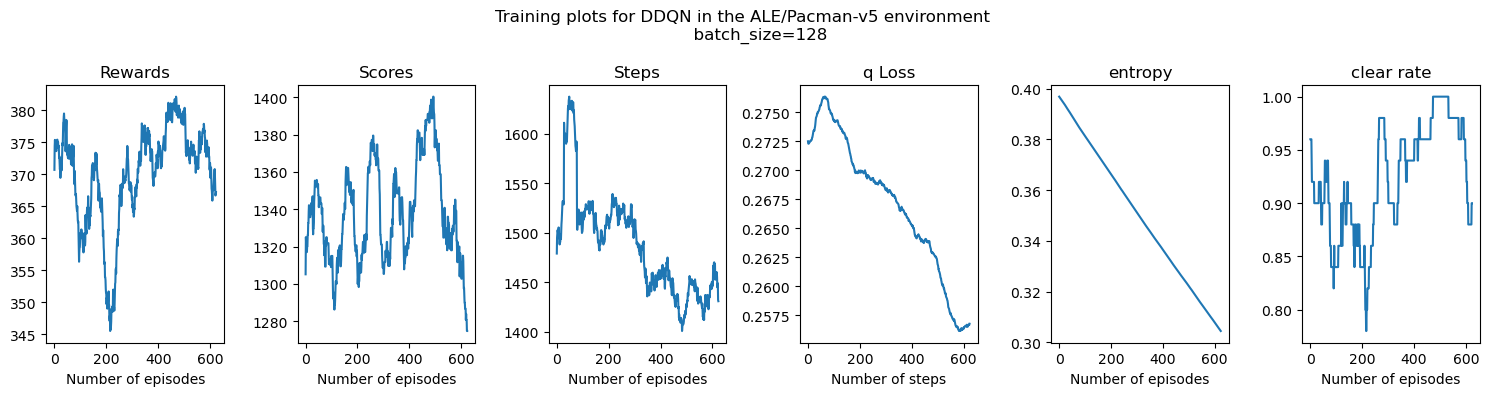

In [38]:
name = "052926_part13"
rolling_length = 50

""" plot the results """

fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(15, 4))
fig.suptitle(
    f"Training plots for {agent.__class__.__name__} in the ALE/Pacman-v5 environment \n \
     batch_size={batch_size}"
)

# rewards
axs[0].set_title("Rewards")
rewards_update_moving_average = (
    np.convolve(np.array(ep_rewards), np.ones(rolling_length), mode="valid")
    / rolling_length
)
axs[0].plot(rewards_update_moving_average)
axs[0].set_xlabel("Number of episodes")

# scores
axs[1].set_title("Scores")
pure_score_moving_average = (
    np.convolve(np.array(ep_scores), np.ones(rolling_length), mode="valid")
    / rolling_length
)
axs[1].plot(pure_score_moving_average)
axs[1].set_xlabel("Number of episodes")

# steps
axs[2].set_title("Steps")
step_moving_average = (
    np.convolve(np.array(ep_steps), np.ones(rolling_length), mode="valid")
    / rolling_length
)
axs[2].plot(step_moving_average)
axs[2].set_xlabel("Number of episodes")

# q loss
axs[3].set_title("q Loss")
q_losses_moving_average = (
    np.convolve(
        np.array(ep_q_losses), np.ones(rolling_length), mode="valid"
    )
    /rolling_length
)
axs[3].plot(q_losses_moving_average)
axs[3].set_xlabel("Number of steps")
plt.tight_layout()

# entropy
axs[4].set_title("entropy")
entropy_moving_average = (
    np.convolve(
        np.array(ep_entropies), np.ones(rolling_length), mode="valid"
    )
    /rolling_length
)
axs[4].plot(entropy_moving_average)
axs[4].set_xlabel("Number of episodes")

# clear rate
axs[5].set_title("clear rate")
clears_moving_average = (
    np.convolve(
        np.array(ep_clears), np.ones(rolling_length), mode="valid"
    )
    /rolling_length
)
axs[5].plot(clears_moving_average)
axs[5].set_xlabel("Number of episodes")
plt.tight_layout()

plt.savefig(f"{name}.png", dpi = 300, bbox_inches = "tight")
np.savetxt(f"{name}_reward.txt", ep_rewards)
np.savetxt(f"{name}_score.txt", ep_scores)
np.savetxt(f"{name}_step.txt", ep_steps)
np.savetxt(f"{name}_q_loss.txt", ep_q_losses)
np.savetxt(f"{name}_entropy.txt", ep_entropies)
np.savetxt(f"{name}_clears.txt", ep_clears)

In [18]:
save_weights = False
load_weights = True

name = "052926_part13_recent"

q_weights_path = f"weights/{name}.hS"
q_t_weights_path = f"weights/{name}_t.hS"
q_sep_weights_path = f"weights/{name}_sep.hS"
q_sep_t_weights_path = f"weights/{name}_sep_t.hS"

if not os.path.exists("weights"):
    os.mkdir("weights")

""" save network weights """
if save_weights:
    torch.save(agent.q.state_dict(), q_weights_path)
    torch.save(agent.q_t.state_dict(), q_t_weights_path)
    np.save(f"weights/replay_r_{name}", agent.replay_buffer_r)
    np.save(f"weights/replay_s_{name}", agent.replay_buffer_s)
    np.save(f"weights/replay_a_{name}", agent.replay_buffer_a)
    np.save(f"weights/replay_d_{name}", agent.replay_buffer_d)
    np.save(f"weights/ptr_{name}", agent.ptr)

""" Load network weights """

if load_weights:
    agent.q.load_state_dict(torch.load(q_weights_path))
    agent.q.eval()
    agent.q_t.load_state_dict(torch.load(q_t_weights_path))
    agent.q_t.eval()

    rb = np.load(f"weights/replay_r_{name}.npy").astype(np.float32)
    sb = np.load(f"weights/replay_s_{name}.npy").astype(np.float32)
    ab = np.load(f"weights/replay_a_{name}.npy").astype(np.int64)
    db = np.load(f"weights/replay_d_{name}.npy").astype(np.float32)
    ptr = np.load(f"weights/ptr_{name}.npy").astype(np.int64)

    min_size = min(rb.shape[0], agent.replay_buffer_r.shape[0])

    agent.replay_buffer_r[:min_size] = rb[-min_size:]
    agent.replay_buffer_s[:min_size] = sb[-min_size:]
    agent.replay_buffer_a[:min_size] = ab[-min_size:]
    agent.replay_buffer_d[:min_size] = db[-min_size:]

    if agent.replay_buffer_r.shape[0] > rb.shape[0]:
        agent.ptr = int(min_size)
    elif agent.replay_buffer_r.shape[0] == rb.shape[0]:
        agent.ptr = int(ptr)
    elif ptr > agent.replay_buffer_r.shape[0]:
        agent.ptr = int(ptr - min_size)
    else:
        agent.ptr = 0
        
    agent.size = int(min_size)
    


/tmp/ipykernel_1267/2600891893.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agent.q.load_state_dict(torch.load(q_weights_path))
/tmp/ipykernel_1267/2600891893.py:29:

In [56]:
entropy_eval = 0.01
num_eval_episodes = 1000

envs_eval = gym.make("ALE/Pacman-v5", frameskip = 1, obs_type = "ram")
envs_eval = ActionRepeat(envs_eval, 4)
envs_eval = Autoreset(envs_eval)

states_eval, info_eval = envs_eval.reset()

agent.q.eval()

clear = 0
step_size = 0
score = 0
life = 0

terminated_eval = False

for i in tqdm(range(num_eval_episodes)):
    while terminated_eval == False:
    
        actions_eval, H_eval = agent.select_action(states_eval, entropy_eval)
    
        states_eval, rewards_eval, terminated_eval, truncated_eval, info_eval = envs_eval.step(actions_eval+1)
    
        score += rewards_eval
        step_size +=1
    
        if np.all(active_pellets == False):
            states_eval, info_eval = envs_eval.reset()
            terminated_eval = True
            clear += 1
    
        if terminated_eval or truncated_eval:
    
            life += info_eval['lives']

    terminated_eval = False

print(f"Average clearance rate: {100*clear/num_eval_episodes}%")
print(f"Average score: {score/num_eval_episodes}")
print(f"Average lives: {life/num_eval_episodes}")
print(f"Average step size: {step_size/num_eval_episodes}")



100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [2:24:42<00:00,  8.68s/it]

Average clearance rate: 96.9%
Average score: 1387.122
Average lives: 3.876
Average step size: 1336.124


In [32]:
""" play a showcase episode """
agent.q.eval()
entropy_v = 0.01

video_folder = "video"

if not os.path.exists(video_folder):
    os.mkdir(video_folder)

env_v = gym.make("ALE/Pacman-v5", render_mode="rgb_array_list", obs_type = "ram", frameskip = 1)
env_v = ActionRepeat(env_v, 4)

# get an initial state
state_v, info_v = env_v.reset()
step = 0

# play one episode
done_v = False
while not done_v:
    # select an action A_{t} using S_{t} as input for the agent
    with torch.no_grad():
        action_v, _ = agent.select_action(state_v, entropy_v)

    # perform the action A_{t} in the environment to get S_{t+1} and R_{t+1}
    state_v, reward_v, terminated_v, truncated_v, info_v = env_v.step(action_v+1)
    step += 1
    
    if np.all(active_pellets == False):
        terminated_v = True

    # update if the environment is done
    done_v = (terminated_v or truncated_v)

def remove_blink(frames, window=2):
    merged = []
    for i in range(0, len(frames), window):
        chunk = frames[i:i+window]
        # pixel-wise max across the chunk
        merged.append(np.max(np.stack(chunk), axis=0).astype(np.uint8))
    return merged

# make a video
frames=env_v.render()
frames_clean = remove_blink(frames, window=4)

save_video(frames=frames_clean, video_folder=video_folder, fps=env_v.metadata["render_fps"])

env_v.close()

print(step)

1249
